# Sepsis Prediction Project
## Time-Series Preprocessing and Feature Engineering

This notebook performs preprocessing on ICU patient time-series data.
We convert raw hourly patient data into statistical features using a sliding window approach.

Steps performed:
1. Load patient data from PSV files
2. Handle missing values
3. Keep first 48 hours of ICU stay
4. Apply rolling window (6 hours)
5. Generate statistical features (mean, std, min, max)
6. Create final dataset for machine learning

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Patient Data

We load patient data from Training Set A and Training Set B.
Each file represents one patient’s ICU time-series data.
We also assign a unique patient_id to each patient.

In [2]:
data = []

for i in range(1, 20001):
    path = f"../data/training_setA/training/p{i:06d}.psv"
    try:
        df = pd.read_csv(path, sep="|")
        df["patient_id"] = f"A_{i:06d}"
        data.append(df)
    except:
        pass

for i in range(1, 20001):
    path = f"../data/training_setB/training/p{i:06d}.psv"
    try:
        df = pd.read_csv(path, sep="|")
        df["patient_id"] = f"B_{i:06d}"
        data.append(df)
    except:
        pass

dataset = pd.concat(data, ignore_index=True)
print("Dataset Shape:", dataset.shape)
dataset.head()

Dataset Shape: (777222, 42)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,A_000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,A_000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,A_000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,A_000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,A_000001


## Missing Value Analysis

We calculate the percentage of missing values in each feature
to understand data quality.

EtCO2               100.000000
TroponinI            99.878027
Bilirubin_direct     99.849464
Fibrinogen           99.232137
Bilirubin_total      98.774739
Alkalinephos         98.543145
AST                  98.506733
Lactate              96.560185
PTT                  95.145531
SaO2                 95.038483
Calcium              95.029091
Phosphate            94.955367
Platelets            93.476896
Creatinine           93.359555
WBC                  92.483229
Magnesium            92.223457
HCO3                 91.953136
BUN                  91.845058
Chloride             91.681141
PaCO2                91.215251
Hgb                  91.158511
BaseExcess           89.559225
Potassium            89.131805
pH                   88.514736
Hct                  88.213020
Glucose              87.757681
FiO2                 85.786300
Temp                 66.208754
Unit1                48.861587
Unit2                48.861587
DBP                  48.055768
SBP                  15.216888
O2Sat   

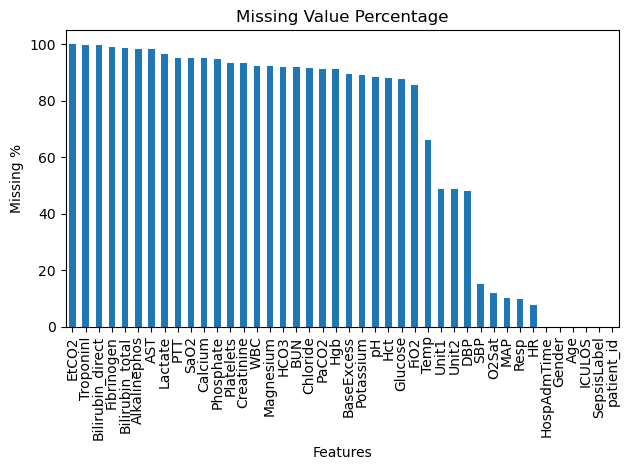

In [3]:
missing_percent = dataset.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

plt.figure()
missing_percent.plot(kind='bar')
plt.title("Missing Value Percentage")
plt.xlabel("Features")
plt.ylabel("Missing %")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Selecting Important Clinical Features

We select clinically relevant features related to sepsis such as:
- Heart Rate
- Oxygen Saturation
- Temperature
- Blood Pressure
- Respiratory Rate
- Lactate
- WBC
- Platelets
- Creatinine
- Glucose
- Age, Gender
- ICU Length of Stay

In [4]:
dataset = dataset[[
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Lactate", "WBC", "Platelets", "Creatinine", "Glucose",
    "Age", "Gender", "ICULOS",
    "SepsisLabel", "patient_id"
]]
print("Selected shape:", dataset.shape)

Selected shape: (777222, 17)


## Keeping First 48 Hours

We use only the first 48 hours of ICU data for early sepsis prediction.

In [5]:
dataset = dataset[dataset["ICULOS"] <= 48]
print("Shape after 48h filter:", dataset.shape)

Shape after 48h filter: (706781, 17)


## Handling Missing Values

We sort data by patient and time, then apply forward fill and backward fill
to handle missing values within each patient's timeline.

In [6]:
dataset = dataset.sort_values(by=["patient_id", "ICULOS"])

dataset = dataset.groupby("patient_id", group_keys=False).apply(
    lambda x: x.ffill().bfill()
)
dataset = dataset.fillna(dataset.median(numeric_only=True))

print("Missing values remaining:")
print(dataset.isnull().sum())

Missing values remaining:
HR             0
O2Sat          0
Temp           0
SBP            0
MAP            0
DBP            0
Resp           0
Lactate        0
WBC            0
Platelets      0
Creatinine     0
Glucose        0
Age            0
Gender         0
ICULOS         0
SepsisLabel    0
patient_id     0
dtype: int64


/var/folders/7j/7tr7ln2s0q758rlztz_f0ypr0000gn/T/ipykernel_90892/665321261.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset = dataset.groupby("patient_id", group_keys=False).apply(


## Rolling Window Feature Engineering

We use a 6-hour sliding window to compute statistical features:
- Mean
- Standard Deviation
- Minimum
- Maximum

These features capture trends and variability in patient vitals over time.

In [7]:
window = 6

cols = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Lactate", "WBC", "Platelets", "Creatinine", "Glucose"
]

for col in cols:
    dataset[col + "_mean"] = dataset.groupby("patient_id")[col].rolling(window).mean().reset_index(0, drop=True)
    dataset[col + "_std"]  = dataset.groupby("patient_id")[col].rolling(window).std().reset_index(0, drop=True)
    dataset[col + "_min"]  = dataset.groupby("patient_id")[col].rolling(window).min().reset_index(0, drop=True)
    dataset[col + "_max"]  = dataset.groupby("patient_id")[col].rolling(window).max().reset_index(0, drop=True)

dataset = dataset.fillna(dataset.median(numeric_only=True))
print("Rolling features added. Missing:", dataset.isnull().sum().sum())

Rolling features added. Missing: 0


## Dropping Raw Vital Signs

After extracting statistical features, we drop the original raw signals
and keep only the engineered features.

In [8]:
dataset = dataset.drop([
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Lactate", "WBC", "Platelets", "Creatinine", "Glucose"
], axis=1)

## Saving Final Dataset

The final dataset is saved as sepsis_final.csv.
This dataset will be used for training machine learning models.

In [9]:
dataset.to_csv("../data/sepsis_final.csv", index=False)

print("Final Dataset Shape:", dataset.shape)
print(dataset["SepsisLabel"].value_counts())
print("Columns:", list(dataset.columns))

Final Dataset Shape: (706781, 53)
SepsisLabel
0    696724
1     10057
Name: count, dtype: int64
Columns: ['Age', 'Gender', 'ICULOS', 'SepsisLabel', 'patient_id', 'HR_mean', 'HR_std', 'HR_min', 'HR_max', 'O2Sat_mean', 'O2Sat_std', 'O2Sat_min', 'O2Sat_max', 'Temp_mean', 'Temp_std', 'Temp_min', 'Temp_max', 'SBP_mean', 'SBP_std', 'SBP_min', 'SBP_max', 'MAP_mean', 'MAP_std', 'MAP_min', 'MAP_max', 'DBP_mean', 'DBP_std', 'DBP_min', 'DBP_max', 'Resp_mean', 'Resp_std', 'Resp_min', 'Resp_max', 'Lactate_mean', 'Lactate_std', 'Lactate_min', 'Lactate_max', 'WBC_mean', 'WBC_std', 'WBC_min', 'WBC_max', 'Platelets_mean', 'Platelets_std', 'Platelets_min', 'Platelets_max', 'Creatinine_mean', 'Creatinine_std', 'Creatinine_min', 'Creatinine_max', 'Glucose_mean', 'Glucose_std', 'Glucose_min', 'Glucose_max']
